In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F

In [12]:
train = pd.read_csv("../data/letters_train_fixed.csv", header=None)

y = train[0] - 1          # 1–26 → 0–25 (PyTorch ожидает с нуля)
X = train.drop(0, axis=1).values / 255.0  # нормализация пикселей

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # ← гарантирует все 26 букв в обоих сплитах
)

print(X_train.shape, X_test.shape)

(71040, 784) (17760, 784)


In [13]:
def make_dataset(X, y):
    X_t = torch.tensor(X, dtype=torch.float32).reshape(-1, 1, 28, 28)
    y_t = torch.tensor(y.values, dtype=torch.long)
    return TensorDataset(X_t, y_t)

train_ds = make_dataset(X_train, y_train)
test_ds  = make_dataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64)

In [14]:
class LetterCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Блок 1: 1×28×28 → 32×14×14
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Блок 2: 32×14×14 → 64×7×7
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Блок 3: 64×7×7 → 128×7×7
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 26),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = LetterCNN().to(device)
print(device)

cpu


In [15]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
NUM_EPOCHS = 15

for epoch in range(NUM_EPOCHS):
    # --- train ---
    model.train()
    total_loss = 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)

        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # --- eval ---
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for X_b, y_b in test_loader:
            preds = model(X_b.to(device)).argmax(dim=1).cpu()
            correct += (preds == y_b).sum().item()
            total   += len(y_b)

    acc = correct / total
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | loss: {avg_loss:.4f} | acc: {acc:.4f}")

Epoch  1/15 | loss: 0.6988 | acc: 0.9110
Epoch  2/15 | loss: 0.3296 | acc: 0.9273
Epoch  3/15 | loss: 0.2667 | acc: 0.9335
Epoch  4/15 | loss: 0.2306 | acc: 0.9351
Epoch  5/15 | loss: 0.2024 | acc: 0.9358
Epoch  6/15 | loss: 0.1868 | acc: 0.9425
Epoch  7/15 | loss: 0.1667 | acc: 0.9416
Epoch  8/15 | loss: 0.1569 | acc: 0.9426
Epoch  9/15 | loss: 0.1439 | acc: 0.9423
Epoch 10/15 | loss: 0.1319 | acc: 0.9440
Epoch 11/15 | loss: 0.1246 | acc: 0.9426
Epoch 12/15 | loss: 0.1166 | acc: 0.9425
Epoch 13/15 | loss: 0.1089 | acc: 0.9448
Epoch 14/15 | loss: 0.1037 | acc: 0.9430
Epoch 15/15 | loss: 0.0995 | acc: 0.9429


In [16]:
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for X_b, y_b in test_loader:
        preds = model(X_b.to(device)).argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_true.extend(y_b.numpy())

labels = [chr(ord('A') + i) for i in range(26)]
print(classification_report(all_true, all_preds, target_names=labels))

              precision    recall  f1-score   support

           A       0.94      0.95      0.94       679
           B       0.97      0.97      0.97       679
           C       0.98      0.98      0.98       684
           D       0.96      0.95      0.96       680
           E       0.96      0.98      0.97       687
           F       0.99      0.97      0.98       679
           G       0.88      0.86      0.87       677
           H       0.98      0.94      0.96       685
           I       0.73      0.80      0.76       686
           J       0.95      0.93      0.94       680
           K       0.98      0.97      0.97       688
           L       0.77      0.72      0.74       683
           M       0.99      0.98      0.98       680
           N       0.95      0.95      0.95       673
           O       0.97      0.98      0.98       682
           P       0.98      0.99      0.98       686
           Q       0.88      0.90      0.89       687
           R       0.95    

Accuracy: 0.9429

Classification Report:
              precision    recall  f1-score   support

           A       0.94      0.95      0.94       679
           B       0.97      0.97      0.97       679
           C       0.98      0.98      0.98       684
           D       0.96      0.95      0.96       680
           E       0.96      0.98      0.97       687
           F       0.99      0.97      0.98       679
           G       0.88      0.86      0.87       677
           H       0.98      0.94      0.96       685
           I       0.73      0.80      0.76       686
           J       0.95      0.93      0.94       680
           K       0.98      0.97      0.97       688
           L       0.77      0.72      0.74       683
           M       0.99      0.98      0.98       680
           N       0.95      0.95      0.95       673
           O       0.97      0.98      0.98       682
           P       0.98      0.99      0.98       686
           Q       0.88      0.90      0

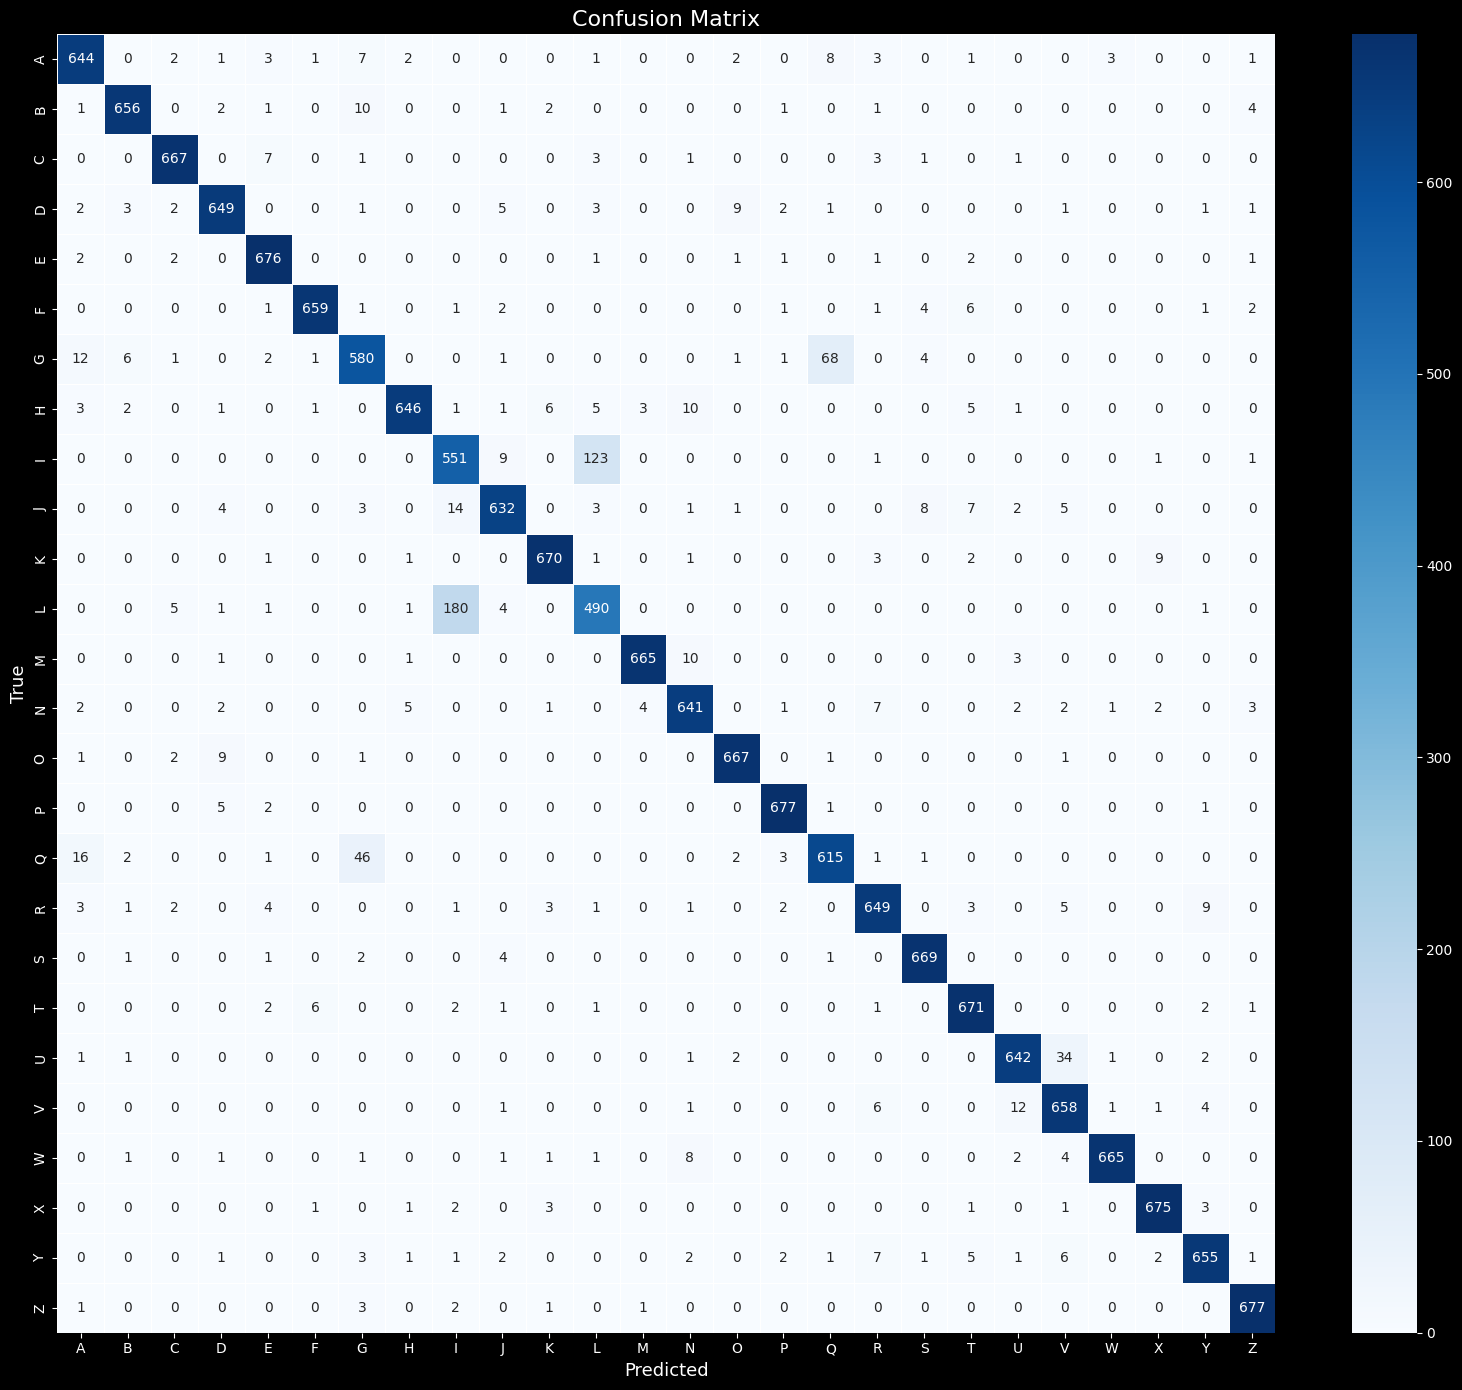

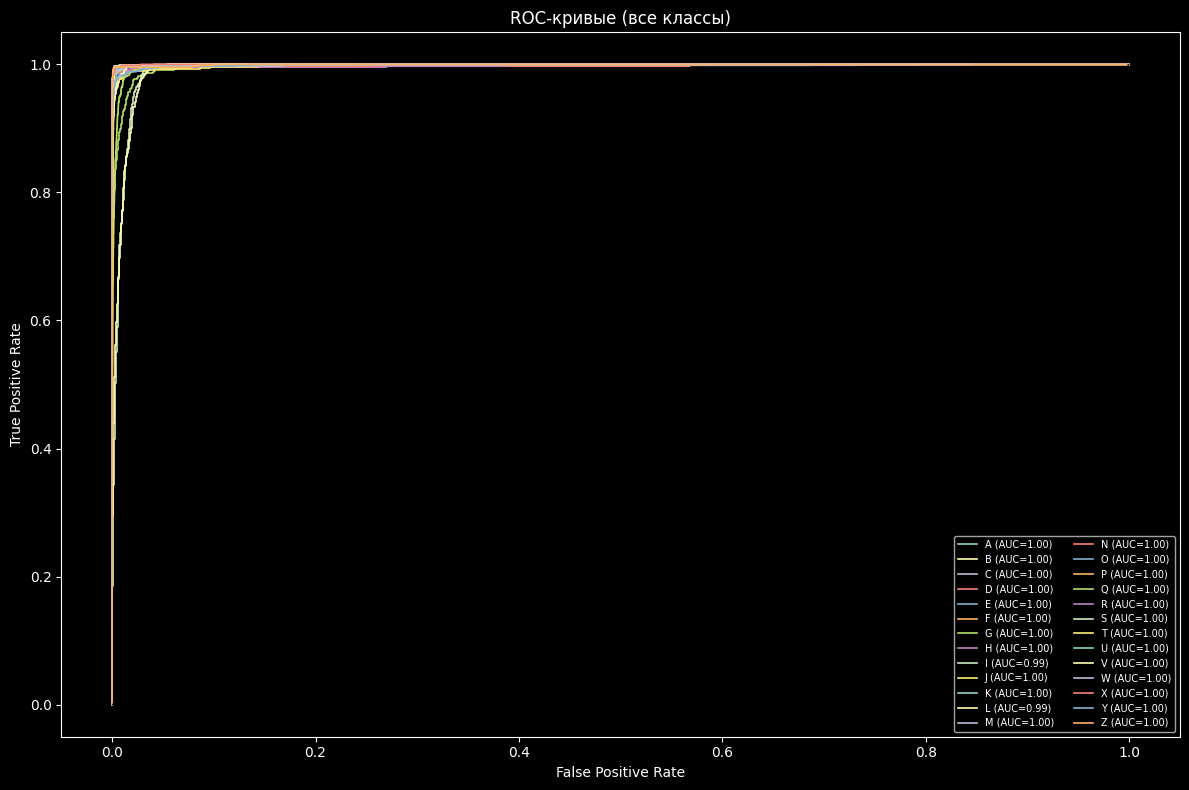

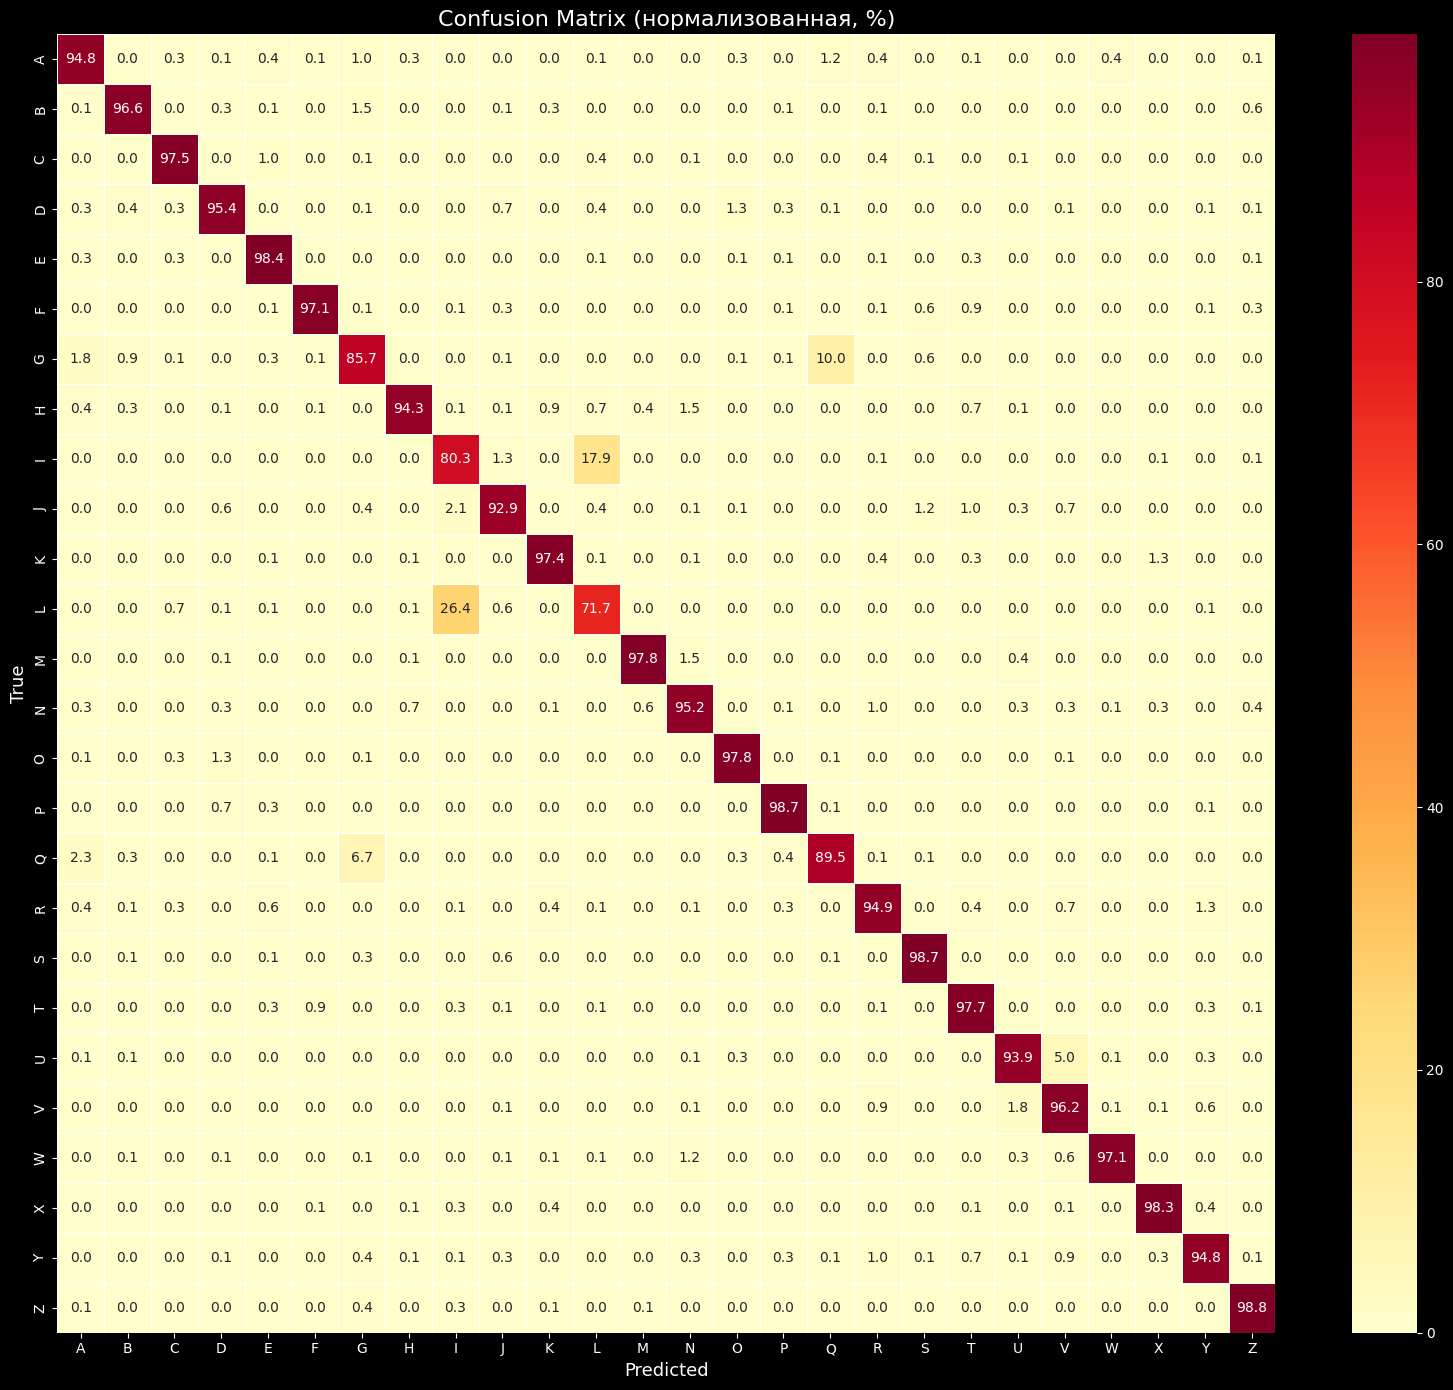


ИТОГОВЫЕ МЕТРИКИ
  Accuracy          : 0.9429
  ROC-AUC (macro)   : 0.9985
  Precision (macro) : 0.9434
  Recall (macro)    : 0.9429
  F1-score (macro)  : 0.9430


In [17]:
labels = [chr(ord('A') + i) for i in range(26)]

# ── Собираем предсказания и вероятности ──────────────────────────────────────
model.eval()
all_preds, all_true, all_probs = [], [], []

with torch.no_grad():
    for X_b, y_b in test_loader:
        logits = model(X_b.to(device))
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_true.extend(y_b.numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_true  = np.array(all_true)

# ── 1. Accuracy ───────────────────────────────────────────────────────────────
acc = accuracy_score(all_true, all_preds)
print(f"Accuracy: {acc:.4f}")

# ── 2. Classification Report (precision, recall, f1) ─────────────────────────
print("\nClassification Report:")
print(classification_report(all_true, all_preds, target_names=labels))

# ── 3. ROC-AUC (One-vs-Rest) ─────────────────────────────────────────────────
y_bin = label_binarize(all_true, classes=list(range(26)))
roc_auc = roc_auc_score(y_bin, all_probs, multi_class='ovr', average='macro')
print(f"ROC-AUC (macro, OvR): {roc_auc:.4f}")

# Per-class AUC
from sklearn.metrics import roc_auc_score
print("\nROC-AUC по классам:")
for i, letter in enumerate(labels):
    auc = roc_auc_score(y_bin[:, i], all_probs[:, i])
    print(f"  {letter}: {auc:.4f}")

# ── 4. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5
)
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('True', fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# ── 5. ROC-кривые (первые 6 букв для наглядности) ────────────────────────────
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(12, 8))
for i in range(26):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    auc_score   = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=1.2, label=f"{labels[i]} (AUC={auc_score:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые (все классы)')
plt.legend(loc='lower right', fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

# ── 6. Нормализованная Confusion Matrix (в %) ────────────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5
)
plt.title('Confusion Matrix (нормализованная, %)', fontsize=16)
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('True', fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_normalized.png", dpi=150)
plt.show()

# ── 7. Итоговая сводка ────────────────────────────────────────────────────────
print("\n" + "="*45)
print("ИТОГОВЫЕ МЕТРИКИ")
print("="*45)
print(f"  Accuracy          : {acc:.4f}")
print(f"  ROC-AUC (macro)   : {roc_auc:.4f}")

from sklearn.metrics import f1_score, precision_score, recall_score
print(f"  Precision (macro) : {precision_score(all_true, all_preds, average='macro'):.4f}")
print(f"  Recall (macro)    : {recall_score(all_true, all_preds, average='macro'):.4f}")
print(f"  F1-score (macro)  : {f1_score(all_true, all_preds, average='macro'):.4f}")
print("="*45)

In [22]:
torch.save(model.state_dict(), "../model/letter_cnn.pth")